# 📊 Análisis Exploratorio de Datos (EDA) — Recaudo de Rentas Cedidas

**Documento de Trabajo para Tesis Maestral**

Este notebook constituye el primer componente del sistema analítico, realizando una exploración exhaustiva
del dataset de recaudo tributario de Rentas Cedidas para Departamentos y Distritos de Colombia.

**Objetivo:** Caracterizar la estructura estadística del recaudo, identificar patrones temporales,
estacionalidad, outliers y distribuciones, sentando las bases empíricas para el modelado predictivo posterior.

---

In [1]:
# Configuración del sistema
import sys
sys.path.insert(0, '.')
sys.path.insert(0, '../scripts')

%run 00_config.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils import cargar_datos, agregar_mensual, test_estacionariedad, formato_pesos

print(f"\n🔬 TESIS: {PROYECTO_NOMBRE}")
print(f"   Periodo de análisis: {PROYECTO_PERIODO}")

  🎨 Tema profesional aplicado — Tipografía serif, paleta académica, DPI 300
✅ Config cargada — Datos: BaseRentasVF_2022_2025.xlsx | Periodo: 2022-01-01 a 2025-12-31
  🎨 Tema profesional activo — DPI 300, tipografía serif, paleta académica


✅ Config cargada — Datos: BaseRentasVF_2022_2025.xlsx | Periodo: 2022-01-01 a 2025-12-31
  🎨 Tema profesional activo — DPI 300, tipografía serif, paleta académica

🔬 TESIS: Sistema de Análisis y Pronóstico de Rentas Cedidas
   Periodo de análisis: 2022-01-01 a 2025-12-31


## 1. Carga y Validación del Dataset

Cargamos la base depurada `BaseRentasVF_limpieza21feb_FINAL.xlsx` que contiene 149,410 observaciones
tras el truncamiento metodológico documentado en la Justificación Metodológica (exclusión 2020 y Ene-Sep 2021
por ruptura estructural COVID-19).

In [2]:
# 1.1 Carga de datos
df = cargar_datos(DATA_FILE)
df.head()

Aviso: 22 registros con ValorRecaudo < 0 (anulaciones fiscales, se conservan).
Datos cargados: 141,753 filas × 15 columnas
   Periodo: 2022-01-03 a 2025-12-31


,FechaRecaudo,NitBeneficiarioAportante,NombreBeneficiarioAportante,ValorRecaudo,Nombre de Rubro,NombreGrupoFuente,CódigoSubGrupoFuente,NombreSubGrupoFuente,CódigoConcepto,NombreConcepto,CódigoTipoRegistro,TipoRegistro,Nombre_SubGrupo_Aportante,Columna1,Columna2
0,2022-01-03,892115015,DEPARTAMENTO DE LA GUAJIRA,2579070.0,Recursos Departamentales y Distritales para As...,ADMINISTRACIÓN DE RENTAS CEDIDAS DE LOS ENTES ...,111,Monopolio de Juegos de Suerte y Azar Entidades...,1102-09,Impuesto De Loterías Foráneas Dptal,1102-09-01,Recaudo,Entidades Territoriales,NaN,NaN
1,2022-01-03,900034608,UNIDAD ADMINISTRATIVA NOESPECIAL DE SALUD DE A...,451350.0,Recursos Departamentales y Distritales para As...,ADMINISTRACIÓN DE RENTAS CEDIDAS DE LOS ENTES ...,111,Monopolio de Juegos de Suerte y Azar Entidades...,1102-09,Impuesto De Loterías Foráneas Dptal,1102-09-01,Recaudo,Entidades Territoriales,NaN,NaN
2,2022-01-03,892099216,DEPARTAMENTO DEL CASANARE,1031220.0,Recursos Departamentales y Distritales para As...,ADMINISTRACIÓN DE RENTAS CEDIDAS DE LOS ENTES ...,111,Monopolio de Juegos de Suerte y Azar Entidades...,1102-09,Impuesto De Loterías Foráneas Dptal,1102-09-01,Recaudo,Entidades Territoriales,NaN,NaN
3,2022-01-03,800094164,GOBERNACION DEL PUTUMAYO,473535.0,Recursos Departamentales y Distritales para As...,ADMINISTRACIÓN DE RENTAS CEDIDAS DE LOS ENTES ...,111,Monopolio de Juegos de Suerte y Azar Entidades...,1102-09,Impuesto De Loterías Foráneas Dptal,1102-09-01,Recaudo,Entidades Territoriales,NaN,NaN
4,2022-01-03,800103196,GOBERNACION DEL GUAVIARE,207825.0,Recursos Departamentales y Distritales para As...,ADMINISTRACIÓN DE RENTAS CEDIDAS DE LOS ENTES ...,111,Monopolio de Juegos de Suerte y Azar Entidades...,1102-09,Impuesto De Loterías Foráneas Dptal,1102-09-01,Recaudo,Entidades Territoriales,NaN,NaN


In [3]:
# 1.2 Resumen estadístico descriptivo
print("\n📋 ESTRUCTURA DEL DATASET")
print(f"   Filas: {df.shape[0]:,}")
print(f"   Columnas: {df.shape[1]}")
print(f"   Tipos de datos:")
print(df.dtypes.value_counts().to_string())

print("\n📊 ESTADÍSTICAS DESCRIPTIVAS — ValorRecaudo")
stats = df['ValorRecaudo'].describe()
for idx, val in stats.items():
    print(f"   {idx:>10s}: {formato_pesos(val)}")

print(f"\n   Valores nulos: {df['ValorRecaudo'].isna().sum()}")
print(f"   Valores negativos: {(df['ValorRecaudo'] < 0).sum()}")
print(f"   Valores cero: {(df['ValorRecaudo'] == 0).sum()}")


📋 ESTRUCTURA DEL DATASET
   Filas: 141,753
   Columnas: 15
   Tipos de datos:
object            9
float64           3
int64             2
datetime64[ns]    1

📊 ESTADÍSTICAS DESCRIPTIVAS — ValorRecaudo
        count: $141,753
         mean: $87.60M
          std: $606.00M
          min: $-483.60M
          25%: $1.23M
          50%: $4.82M
          75%: $19.32M
          max: $76.58MM

   Valores nulos: 0
   Valores negativos: 22
   Valores cero: 3


## 2. Agregación a Serie Mensual

Para el análisis de series de tiempo, se agrega el recaudo transaccional a frecuencia mensual (*Monthly Start*).
Esta regularización es necesaria para aplicar modelos SARIMA, Prophet y LSTM.

In [4]:
# 2.1 Agregación mensual
df_mensual = agregar_mensual(df)

print(f"\n📊 Serie Mensual:")
print(f"   Recaudo promedio: {formato_pesos(df_mensual['Recaudo_Neto'].mean())}")
print(f"   Recaudo máximo:   {formato_pesos(df_mensual['Recaudo_Neto'].max())} ({df_mensual['Recaudo_Neto'].idxmax().strftime('%B %Y')})")
print(f"   Recaudo mínimo:   {formato_pesos(df_mensual['Recaudo_Neto'].min())} ({df_mensual['Recaudo_Neto'].idxmin().strftime('%B %Y')})")
print(f"   Coef. Variación:  {df_mensual['Recaudo_Neto'].std()/df_mensual['Recaudo_Neto'].mean()*100:.1f}%")

✅ Serie mensual: 48 observaciones

📊 Serie Mensual:
   Recaudo promedio: $258.69MM
   Recaudo máximo:   $468.98MM (January 2025)
   Recaudo mínimo:   $161.69MM (April 2023)
   Coef. Variación:  27.3%


## 3. Visualización de la Serie de Tiempo

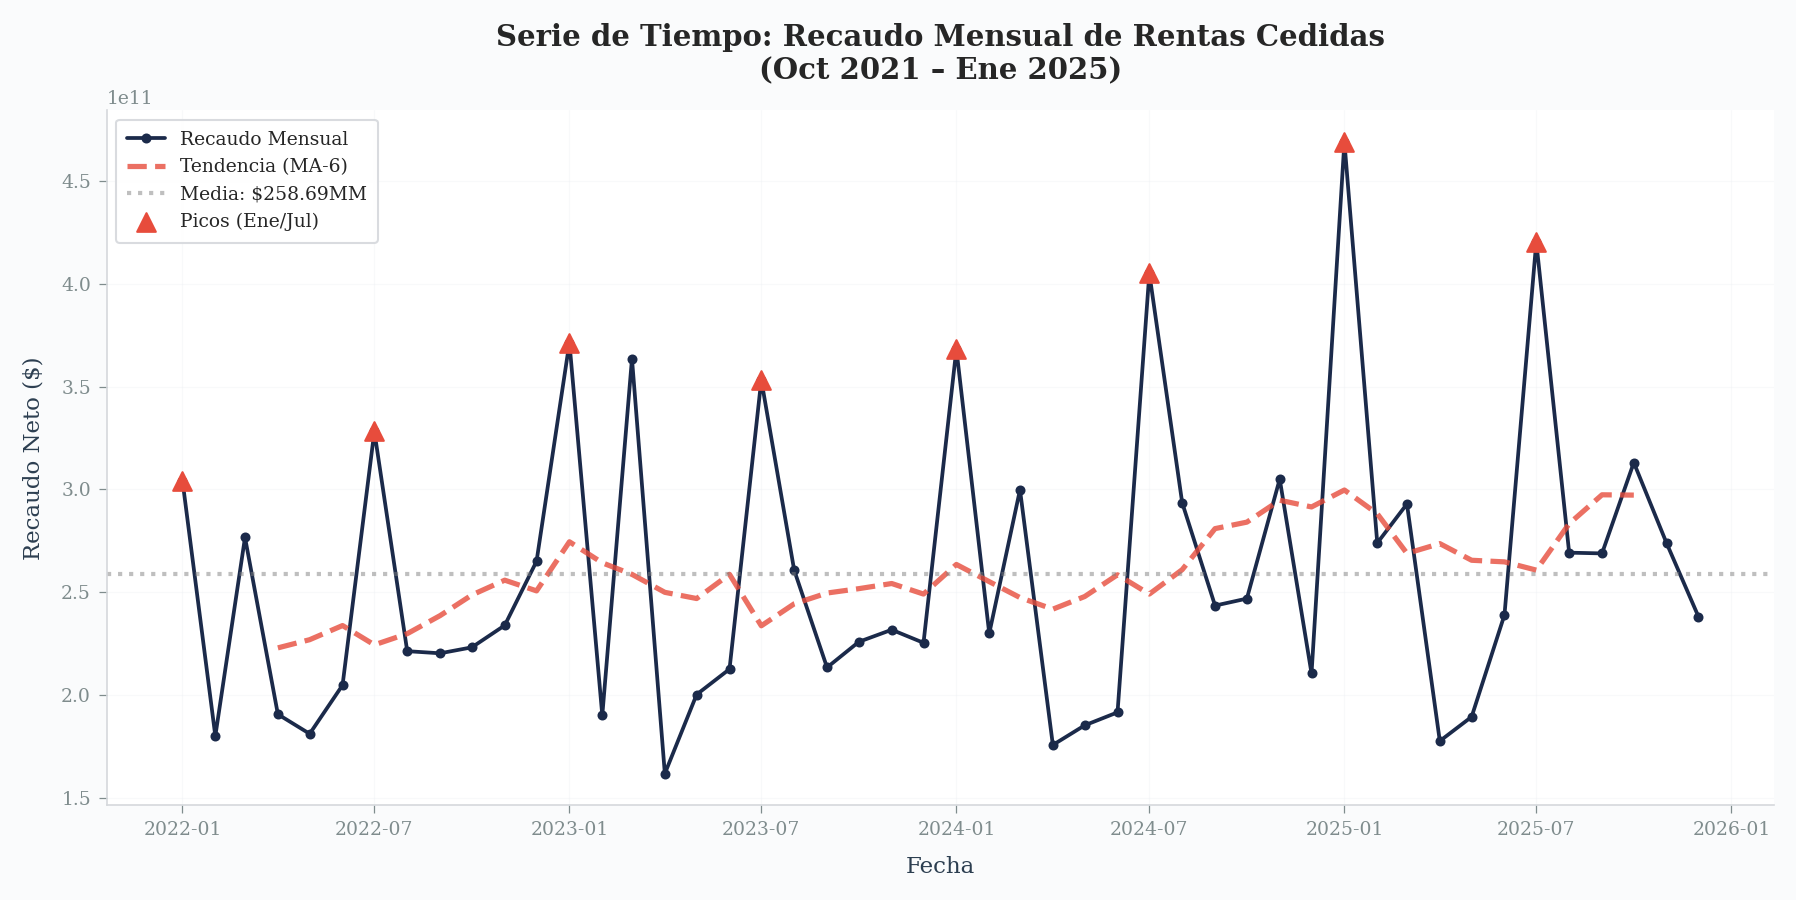

In [5]:
# 3.1 Serie de tiempo completa con tendencia
fig, ax = plt.subplots(figsize=FIGSIZE_STANDARD)

ax.plot(df_mensual.index, df_mensual['Recaudo_Neto'], 
        color=COLORES['real'], linewidth=1.8, marker='o', markersize=4, label='Recaudo Mensual')

# Media móvil 6 meses (tendencia)
rolling = df_mensual['Recaudo_Neto'].rolling(window=6, center=True).mean()
ax.plot(rolling.index, rolling.values, color='#E74C3C', linewidth=2.5, 
        linestyle='--', label='Tendencia (MA-6)', alpha=0.8)

# Línea de media global
media = df_mensual['Recaudo_Neto'].mean()
ax.axhline(y=media, color='gray', linestyle=':', alpha=0.5, label=f'Media: {formato_pesos(media)}')

# Marcar picos de Enero y Julio
picos = df_mensual[df_mensual.index.month.isin(MESES_PICO)]
ax.scatter(picos.index, picos['Recaudo_Neto'], color='#E74C3C', s=80, zorder=5, 
           marker='^', label='Picos (Ene/Jul)')

ax.set_title('Serie de Tiempo: Recaudo Mensual de Rentas Cedidas\n(Oct 2021 – Ene 2025)', fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Recaudo Neto ($)')
ax.legend(loc='upper left', framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(OUTPUTS_FIGURES / '01_serie_tiempo_recaudo.png', dpi=150, bbox_inches='tight')
plt.show()

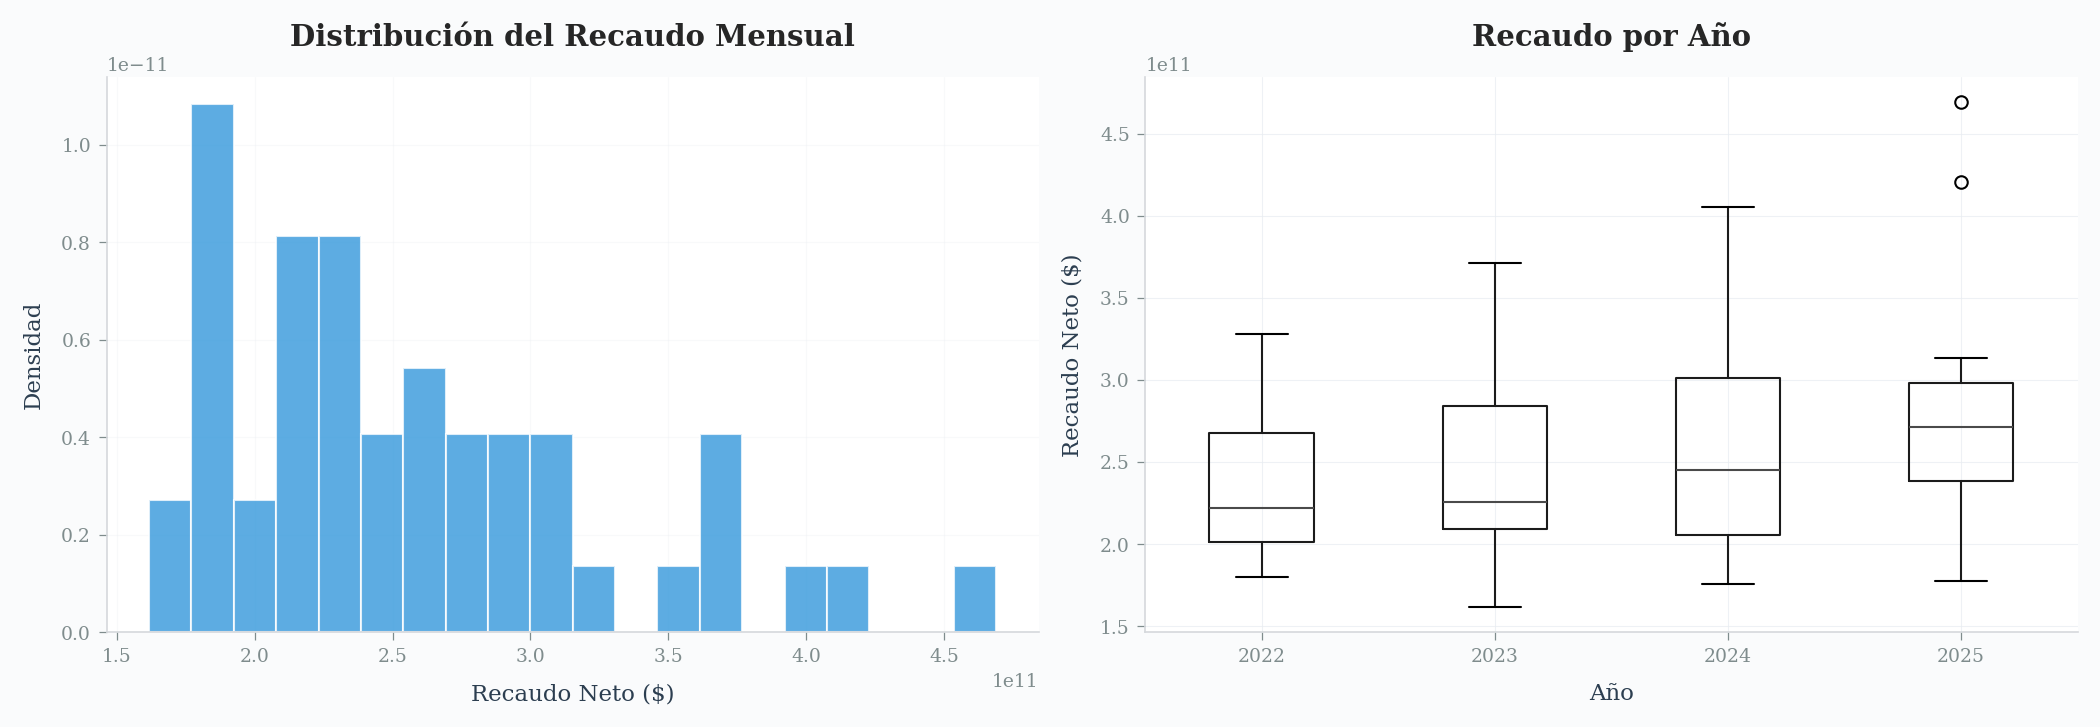

In [6]:
# 3.2 Distribución del recaudo mensual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df_mensual['Recaudo_Neto'], bins=20, color='#3498DB', edgecolor='white', alpha=0.8, density=True)
axes[0].set_title('Distribución del Recaudo Mensual')
axes[0].set_xlabel('Recaudo Neto ($)')
axes[0].set_ylabel('Densidad')
axes[0].grid(True, alpha=0.3)

# Box plot por año
df_box = df_mensual.copy()
df_box['Año'] = df_box.index.year
df_box.boxplot(column='Recaudo_Neto', by='Año', ax=axes[1])
axes[1].set_title('Recaudo por Año')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Recaudo Neto ($)')
plt.suptitle('')

plt.tight_layout()
fig.savefig(OUTPUTS_FIGURES / '01_distribucion_recaudo.png', dpi=150, bbox_inches='tight')
plt.show()

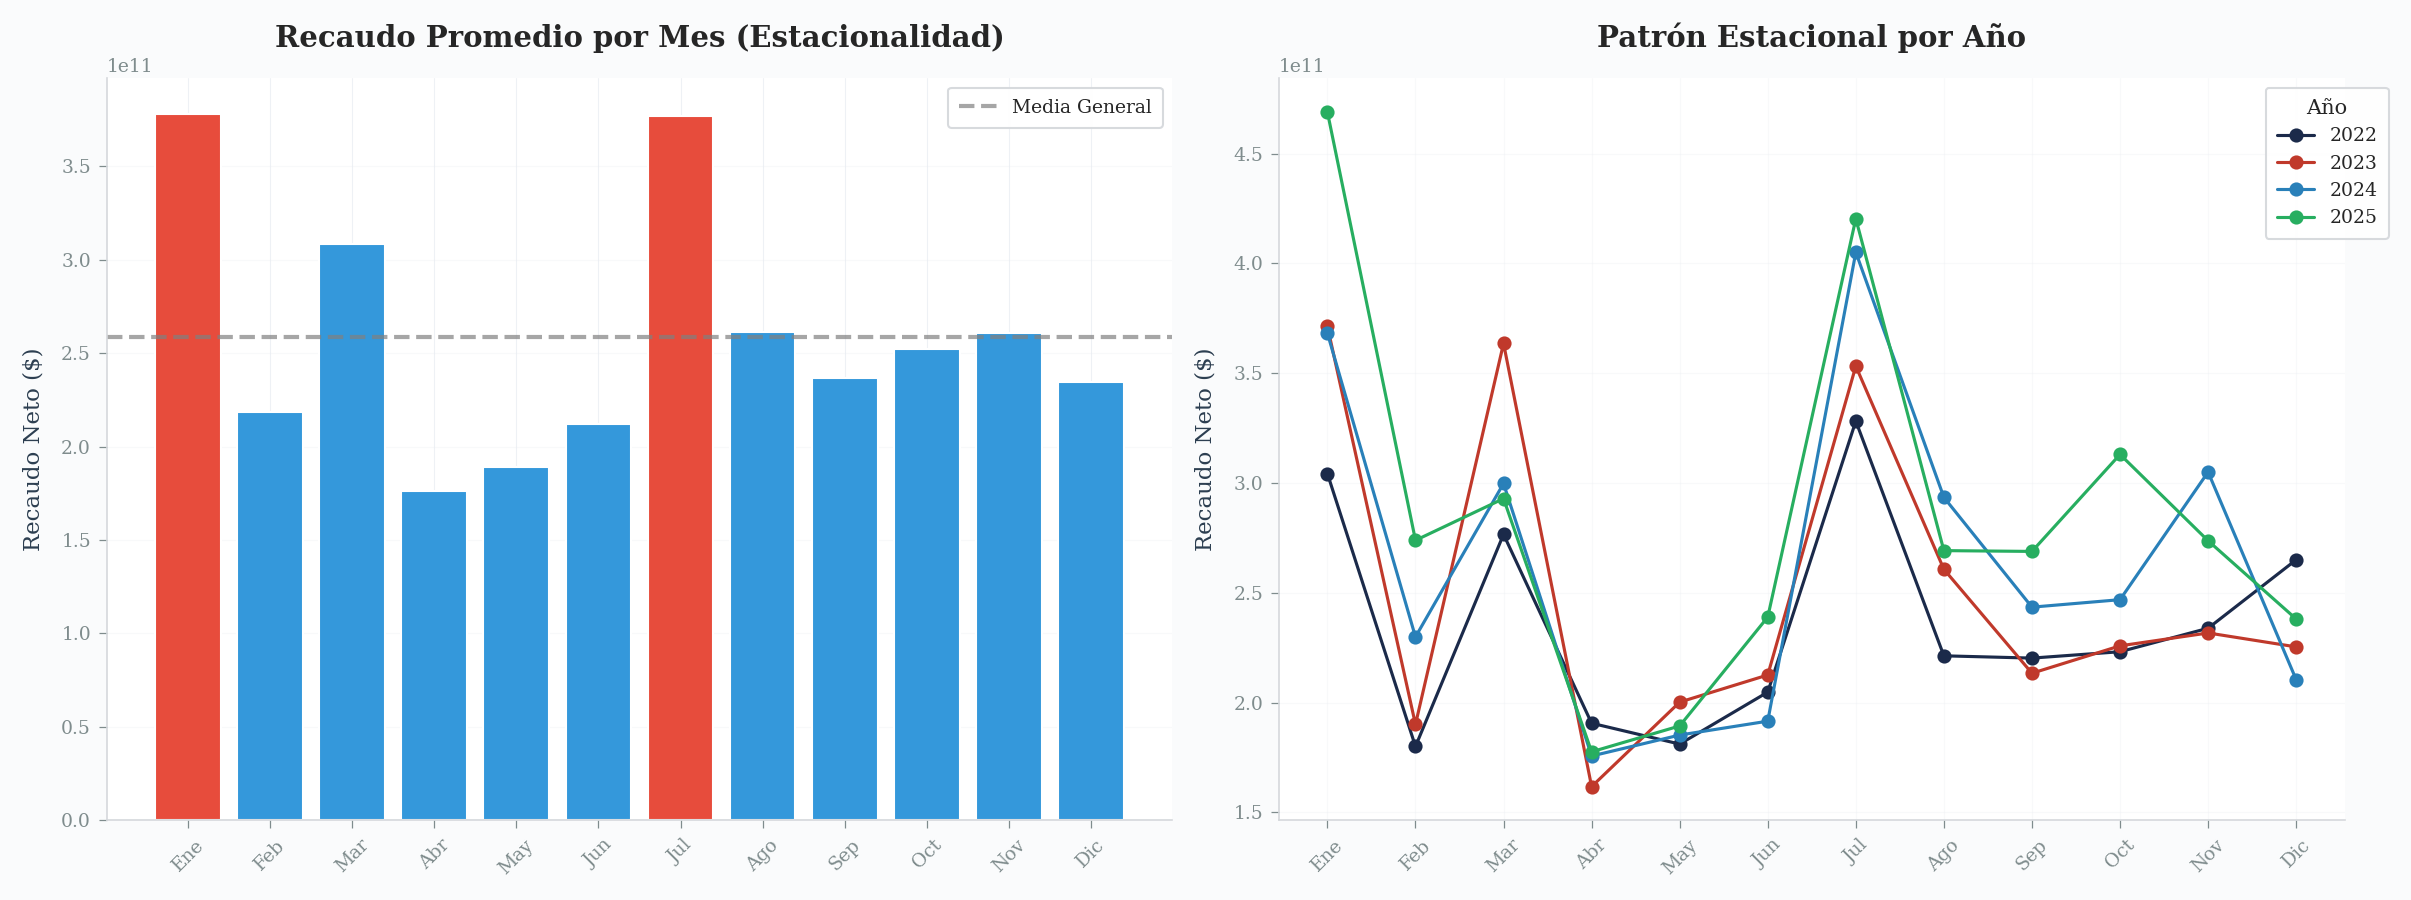

In [7]:
# 3.3 Análisis de estacionalidad por mes
df_estacional = df_mensual.copy()
df_estacional['Mes'] = df_estacional.index.month
df_estacional['Año'] = df_estacional.index.year

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barplot promedio por mes
meses_nombres = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
promedio_mes = df_estacional.groupby('Mes')['Recaudo_Neto'].mean()
colores_bar = ['#E74C3C' if m in MESES_PICO else '#3498DB' for m in promedio_mes.index]

axes[0].bar(range(1,13), promedio_mes.values, color=colores_bar, edgecolor='white')
axes[0].set_xticks(range(1,13))
axes[0].set_xticklabels(meses_nombres, rotation=45)
axes[0].set_title('Recaudo Promedio por Mes (Estacionalidad)')
axes[0].set_ylabel('Recaudo Neto ($)')
axes[0].axhline(y=promedio_mes.mean(), color='gray', linestyle='--', alpha=0.7, label='Media General')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Lines por año
for año in sorted(df_estacional['Año'].unique()):
    data_año = df_estacional[df_estacional['Año'] == año]
    axes[1].plot(data_año['Mes'], data_año['Recaudo_Neto'], 'o-', label=str(año), linewidth=1.5)

axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(meses_nombres, rotation=45)
axes[1].set_title('Patrón Estacional por Año')
axes[1].set_ylabel('Recaudo Neto ($)')
axes[1].legend(title='Año', bbox_to_anchor=(1.05, 1))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(OUTPUTS_FIGURES / '01_estacionalidad_mensual.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Pruebas de Estacionariedad

Aplicamos las pruebas **ADF** (Dickey-Fuller Aumentada) y **KPSS** para determinar si la serie requiere
diferenciación antes del modelado SARIMA.

In [8]:
# 4.1 Test en nivel
resultados_nivel = test_estacionariedad(df_mensual['Recaudo_Neto'], 'Recaudo Neto (Nivel)')

# 4.2 Test en primera diferencia
diff1 = df_mensual['Recaudo_Neto'].diff().dropna()
resultados_diff = test_estacionariedad(diff1, 'Recaudo Neto (Diff-1)')


  PRUEBAS DE ESTACIONARIEDAD: Recaudo Neto (Nivel)

📊 Prueba ADF (H0: raíz unitaria)
   Estadístico: -1.9845
   p-valor:     0.2934
   Resultado:   ⚠️ NO estacionaria

📊 Prueba KPSS (H0: estacionaria)
   Estadístico: 0.2706
   p-valor:     0.1000
   Resultado:   ✅ Estacionaria

  PRUEBAS DE ESTACIONARIEDAD: Recaudo Neto (Diff-1)

📊 Prueba ADF (H0: raíz unitaria)
   Estadístico: -6.7699
   p-valor:     0.0000
   Resultado:   ✅ Estacionaria

📊 Prueba KPSS (H0: estacionaria)
   Estadístico: 0.0508
   p-valor:     0.1000
   Resultado:   ✅ Estacionaria


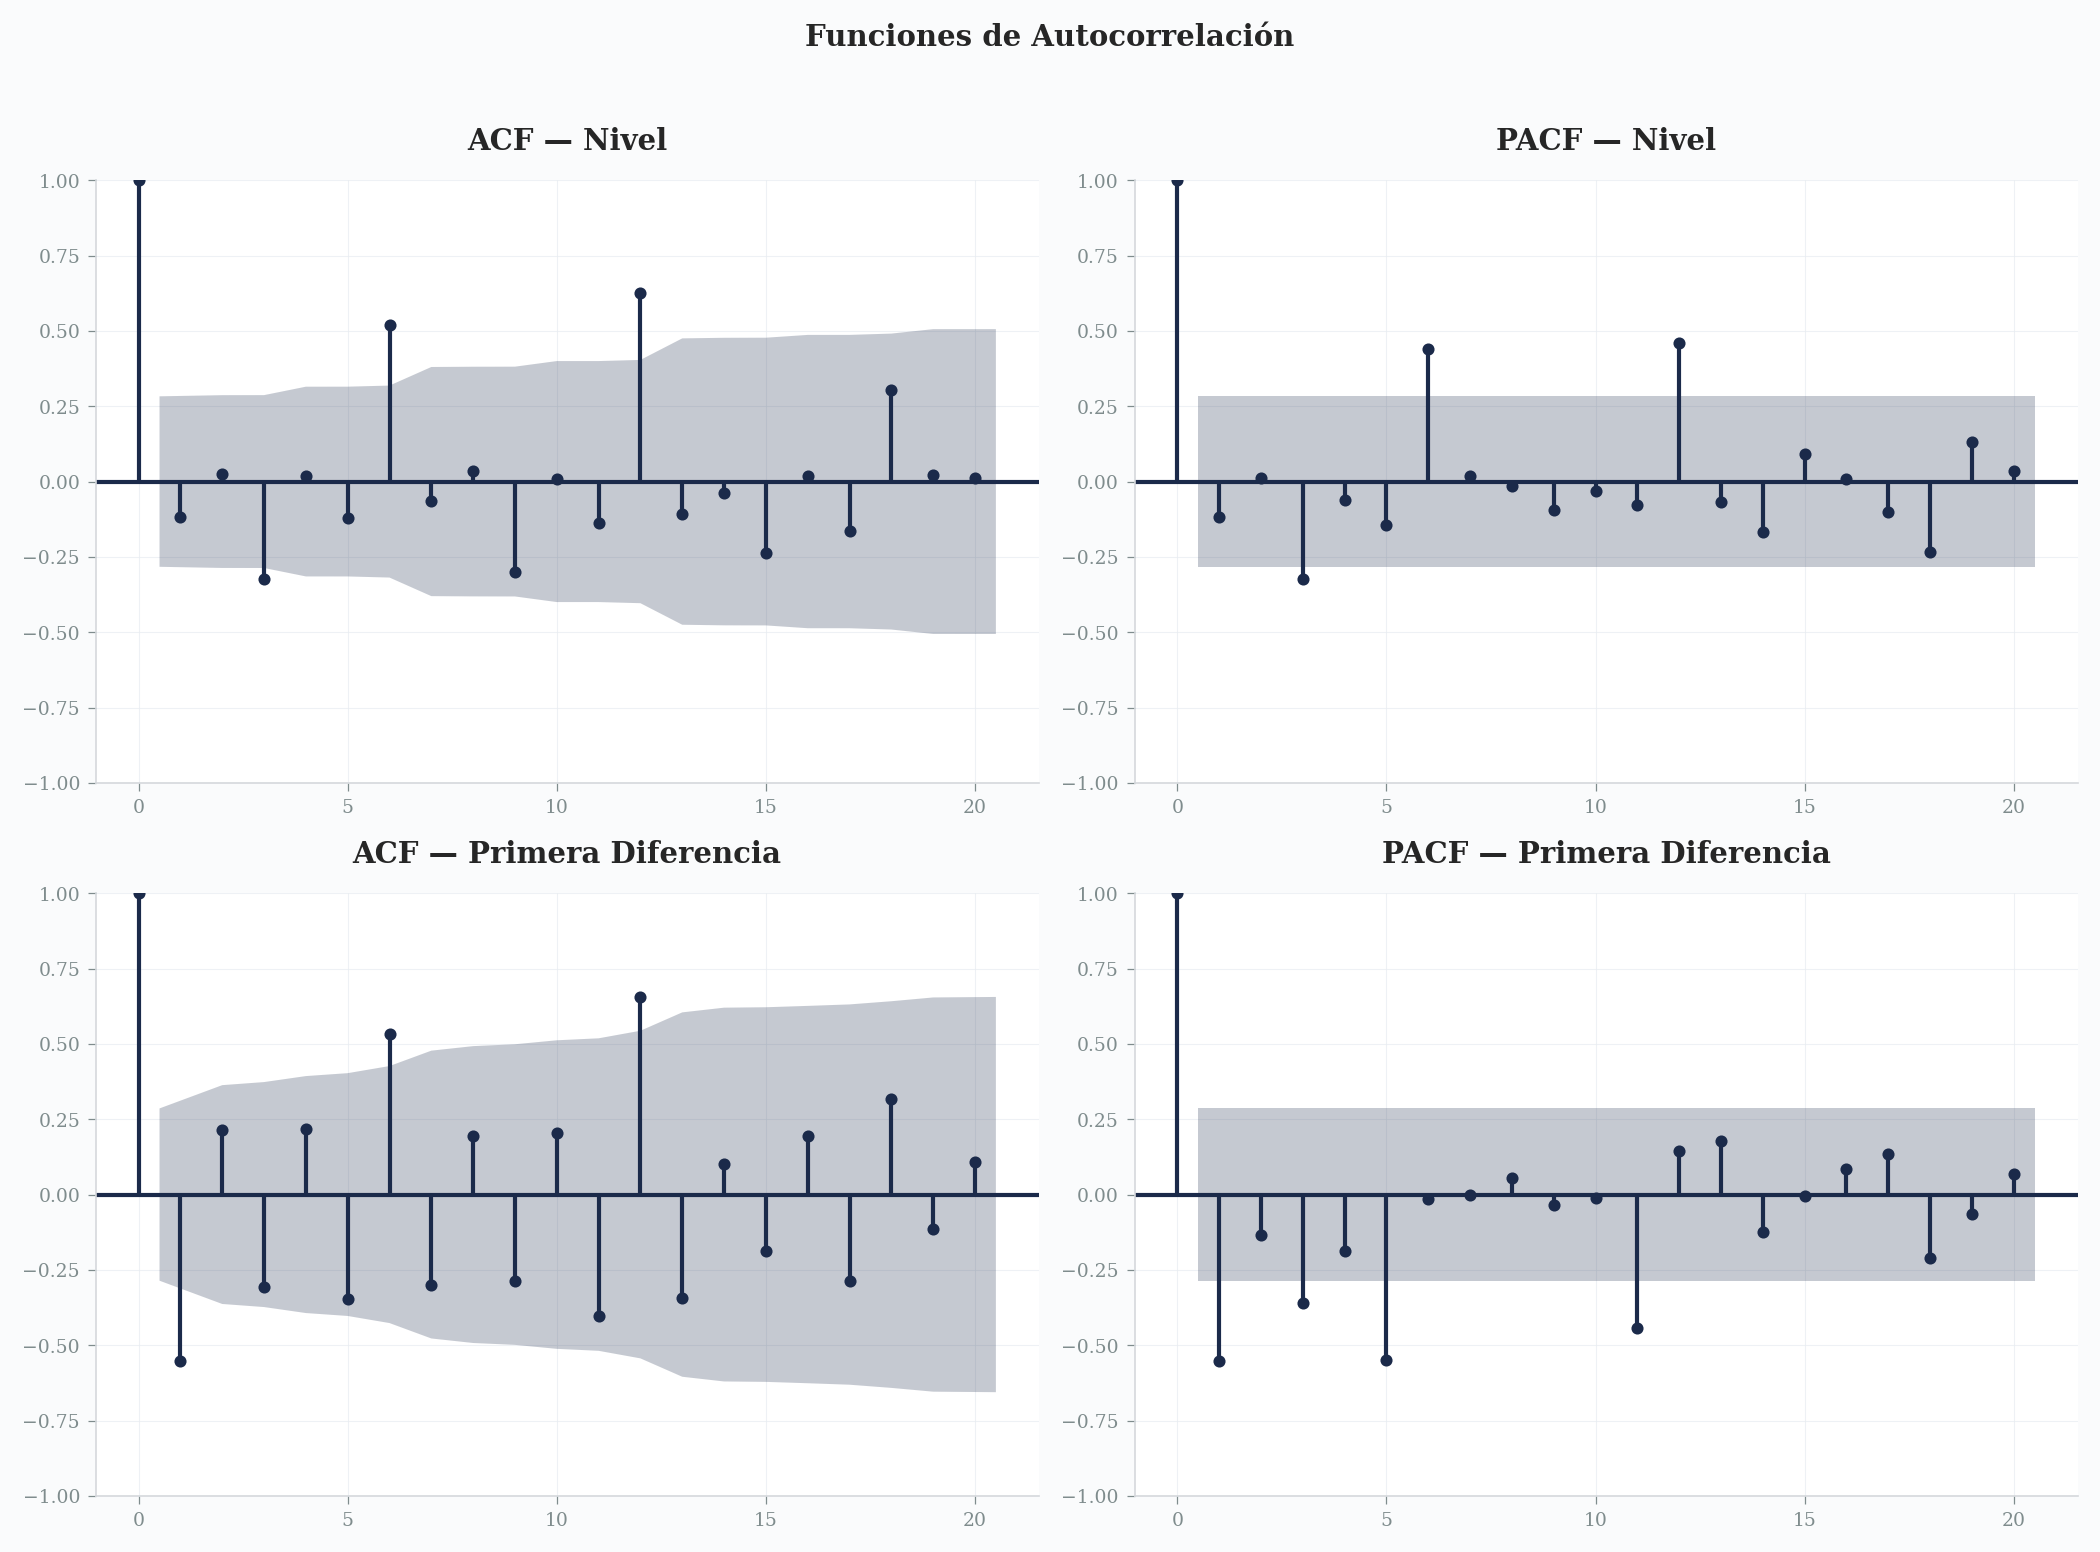

In [9]:
# 4.3 ACF y PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plot_acf(df_mensual['Recaudo_Neto'].dropna(), lags=20, ax=axes[0,0], title='ACF — Nivel')
plot_pacf(df_mensual['Recaudo_Neto'].dropna(), lags=20, ax=axes[0,1], title='PACF — Nivel')
plot_acf(diff1, lags=20, ax=axes[1,0], title='ACF — Primera Diferencia')
plot_pacf(diff1, lags=20, ax=axes[1,1], title='PACF — Primera Diferencia')

plt.suptitle('Funciones de Autocorrelación', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig(OUTPUTS_FIGURES / '01_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Análisis de Outliers

In [10]:
# 5.1 Detección de outliers (método IQR)
Q1 = df_mensual['Recaudo_Neto'].quantile(0.25)
Q3 = df_mensual['Recaudo_Neto'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_mensual[(df_mensual['Recaudo_Neto'] < lower) | (df_mensual['Recaudo_Neto'] > upper)]

print(f"\n🔍 DETECCIÓN DE OUTLIERS (IQR)")
print(f"   Rango normal: [{formato_pesos(lower)} — {formato_pesos(upper)}]")
print(f"   Outliers detectados: {len(outliers)}")
if len(outliers) > 0:
    for idx, row in outliers.iterrows():
        print(f"   ⚠️ {idx.strftime('%Y-%m')}: {formato_pesos(row['Recaudo_Neto'])}")


🔍 DETECCIÓN DE OUTLIERS (IQR)
   Rango normal: [$79.97MM — $424.06MM]
   Outliers detectados: 1
   ⚠️ 2025-01: $468.98MM


In [11]:
# 5.2 Exportar serie mensual para los siguientes notebooks
df_mensual.to_csv(DATA_PROCESSED / 'serie_mensual.csv')
print(f"\n💾 Serie mensual exportada: {DATA_PROCESSED / 'serie_mensual.csv'}")

print("\n" + "="*60)
print("  ✅ EDA COMPLETADO — Proceder con 02_Estacionalidad.ipynb")
print("="*60)


💾 Serie mensual exportada: C:\Users\efren\Music\ESTRUCTURA DATOS RENTAS\data\processed\serie_mensual.csv

  ✅ EDA COMPLETADO — Proceder con 02_Estacionalidad.ipynb
